# E09 Muon Geometry Diagnostics

### Problem

This notebook is a diagnostic experiment rather than a new benchmark objective. It runs representative Matrix Sensing and Matrix Factorization instances and records the geometry of gradients and optimizer updates.

For Matrix Sensing settings,

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad f(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2,$$

with Gaussian measurements, $m=\alpha dr$, direct initialization $X_0=10^{-2}G_0$, and the specified spectrum, condition number, noise, and sample multiplier. For Matrix Factorization settings,

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\lVert W_1W_2\cdots W_{10}-X^\star\rVert_F^2,$$

with Gaussian endpoint initialization and identity middle factors. All targets use the Gaussian QR spectral construction $X^\star=U\operatorname{diag}(s)V^\top$.

At recorded steps, the notebook stores gradients $G_t$, optimizer updates $U_t$, represented matrices $\widehat X_t$, and recovery error. The main geometric statistics are effective rank, stable rank, descent alignment, and relative step size:

$$\cos_t=\frac{\langle -G_t,U_t\rangle}{\lVert G_t\rVert_F\lVert U_t\rVert_F},\qquad \rho_t=\frac{\lVert U_t\rVert_F}{\lVert \theta_t\rVert_F}.$$

For factorized runs these diagnostics are aggregated over the ten trainable factors.


## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E09 geometry diagnostics"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(10))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 600

BASE_SPEC = dict(
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    diagnostic_every=1 if SMOKE_TEST else 10,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-4,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SETTINGS = [
    dict(setting="MS-easy", problem="MatrixSensing", spectrum="hard-cutoff", kappa=1.0, m_multiplier=8, noise=0.0, init_scale=0.01),
    dict(setting="MS-hard-learnable", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=6, noise=0.0, init_scale=0.01),
    dict(setting="MS-undersampled-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=1, noise=0.0, init_scale=0.01),
    dict(setting="MS-noisy-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=4, noise=0.03, init_scale=0.01),
    dict(setting="MF-standard", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-tiny-init", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1e-4),
    dict(setting="MF-overparam", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=20, left_scale=0.01, right_scale=0.01),
    dict(setting="MF-imbalanced", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **setting, "algo": algo, "seed": seed}
    for setting in SETTINGS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}, diagnostic_every={BASE_SPEC['diagnostic_every']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=600, diagnostic_every=10
runs=400, max_total_steps=240000


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,spectrum,kappa,m_multiplier,noise,init_scale,algo,seed,factor_rank,left_scale,right_scale
0,0,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,0,NaN,NaN,NaN
1,1,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,1,NaN,NaN,NaN
2,2,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,2,NaN,NaN,NaN
3,3,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,3,NaN,NaN,NaN
4,4,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,8.0,0.0,0.01,Muon,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SGD,5,5.0,0.0001,1.0
396,396,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SGD,6,5.0,0.0001,1.0
397,397,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SGD,7,5.0,0.0001,1.0
398,398,60,5,0.01,600,10,True,100,20,0.0001,...,hard-cutoff,1.0,NaN,NaN,NaN,SGD,8,5.0,0.0001,1.0


### Pseudocode

```text
for each representative setting, optimizer, seed:
    initialize the corresponding Matrix Sensing or Matrix Factorization problem
    define step(state): loss -> backward -> clone gradients -> optimizer.step -> actual parameter update
    every diagnostic interval, record gradient rank, update rank, cosine with negative gradient, step size, and singular-value recovery
    stop on max iterations, divergence, or patience-based early stopping
compare final performance with the geometry time series
```


### Worker Definition


In [ ]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    diagnostic_every = int(run["diagnostic_every"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    if run["problem"] == "MatrixSensing":
        problem = problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist="normal",
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            m_multiplier=float(run["m_multiplier"]),
        )
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        params = [x]
        estimate = lambda: x.detach()
        objective = lambda: problem.loss(x)
        factor_metrics = lambda: {}
    else:
        factor_rank = int(run["factor_rank"])
        problem = problems.MatrixFactorization.make_matrix_factorization_problem(
            d,
            rank,
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
            factor_rank=factor_rank,
            num_factors=int(run.get("num_factors", 10)),
        )
        factor_inits = problems.MatrixFactorization.initialize_factor_chain(
            d, factor_rank, seed=seed + 3000, device=device, dtype=dtype,
            num_factors=int(run.get("num_factors", 10)),
            left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
        )
        factors = [torch.nn.Parameter(factor) for factor in factor_inits]
        params = factors
        estimate = lambda: problem.estimate(*factors).detach()
        objective = lambda: problem.loss(*factors)
        factor_metrics = lambda: {
            "left_norm": float(factors[0].detach().norm().cpu()),
            "right_norm": float(factors[-1].detach().norm().cpu()),
            "factor_norm_mean": float(np.mean([factor.detach().norm().cpu().item() for factor in factors])),
            "balancedness": util.diagnostics.balancedness(*factors),
        }

    optimizer = make_optimizer(run["algo"], params, float(run["lr"]), rank)
    initial_loss = float(objective().detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    for step_index in range(1, iters + 1):
        optimizer.zero_grad(set_to_none=True)
        loss = objective()
        loss.backward()
        gradients = [param.grad.detach().clone() for param in params]
        before = [param.detach().clone() for param in params]
        optimizer.step()
        updates = [param.detach() - old for param, old in zip(params, before)]
        loss_value = float(loss.detach().cpu())

        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and step_index >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"
        elif step_index == iters:
            stop_reason = "max_iters"

        should_record = step_index == 1 or step_index % diagnostic_every == 0 or bool(stop_reason)
        if should_record:
            x_hat = estimate()
            grad_stats = util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad")
            update_stats = util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update")
            row = {
                **run,
                "initial_loss": initial_loss,
                "step": step_index,
                "loss": loss_value,
                "best_loss": best_loss,
                "early_stop_wait": early_stop_wait,
                "elapsed_s": time.perf_counter() - start_time,
                "stop_reason": stop_reason,
                "relative_matrix_error": util.diagnostics.relative_matrix_error(x_hat, problem.target),
                "solution_effective_rank": util.diagnostics.effective_rank(x_hat),
                "top_sv_relative_error": util.diagnostics.top_singular_value_error(x_hat, problem.target, k=rank),
                "grad_update_cosine": util.diagnostics.descent_alignment(gradients, updates),
                "relative_step_size": util.diagnostics.relative_step_size(before, updates),
                "update_to_grad_norm_ratio": update_stats["update_fro_norm"] / max(grad_stats["grad_fro_norm"], 1e-12),
                **grad_stats,
                **update_stats,
                **factor_metrics(),
            }
            target_sv = torch.linalg.svdvals(problem.target.detach())[:rank]
            solution_sv = torch.linalg.svdvals(x_hat.detach())[:rank]
            for idx in range(rank):
                row[f"target_sv_{idx + 1}"] = float(target_sv[idx].cpu()) if idx < len(target_sv) else 0.0
                row[f"solution_sv_{idx + 1}"] = float(solution_sv[idx].cpu()) if idx < len(solution_sv) else 0.0
            rows.append(row)
        if stop_reason:
            break

    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E09 geometry diagnostics:   0%|          | 0/400 [00:00<?, ?run/s]

E09 geometry diagnostics:   0%|          | 1/400 [00:38<4:12:54, 38.03s/run]

E09 geometry diagnostics:   2%|▏         | 8/400 [00:39<23:33,  3.61s/run]  

E09 geometry diagnostics:   4%|▍         | 15/400 [00:46<14:06,  2.20s/run]

E09 geometry diagnostics:   5%|▍         | 19/400 [00:49<10:35,  1.67s/run]

...

E09 geometry diagnostics:  47%|████▋     | 187/400 [16:12<50:08, 14.12s/run]

E09 geometry diagnostics:  57%|█████▋    | 228/400 [16:13<17:36,  6.14s/run]

E09 geometry diagnostics:  86%|████████▋ | 345/400 [16:14<01:42,  1.86s/run]

E09 geometry diagnostics: 100%|██████████| 400/400 [16:15<00:00,  2.44s/run]

,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_sv_2,target_sv_3,solution_sv_3,target_sv_4,solution_sv_4,target_sv_5,solution_sv_5,left_norm,right_norm,balancedness
0,0,60,5,0.01,600,10,True,100,20,0.0001,...,0.138572,1.0,0.136101,1.0,0.127884,1.0,0.125979,NaN,NaN,NaN
1,0,60,5,0.01,600,10,True,100,20,0.0001,...,0.184069,1.0,0.177425,1.0,0.174451,1.0,0.173582,NaN,NaN,NaN
2,0,60,5,0.01,600,10,True,100,20,0.0001,...,0.263448,1.0,0.260810,1.0,0.252213,1.0,0.242799,NaN,NaN,NaN
3,0,60,5,0.01,600,10,True,100,20,0.0001,...,0.352749,1.0,0.346473,1.0,0.328584,1.0,0.326736,NaN,NaN,NaN
4,0,60,5,0.01,600,10,True,100,20,0.0001,...,0.440691,1.0,0.438002,1.0,0.422635,1.0,0.412300,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4946,399,60,5,0.01,600,10,True,100,20,0.0001,...,0.032692,1.0,0.011321,1.0,0.005440,1.0,0.005071,0.006707,17.002651,1.000000
4947,399,60,5,0.01,600,10,True,100,20,0.0001,...,0.038586,1.0,0.013224,1.0,0.006040,1.0,0.005023,0.007885,17.002652,0.999999
4948,399,60,5,0.01,600,10,True,100,20,0.0001,...,0.044409,1.0,0.015162,1.0,0.006698,1.0,0.004972,0.009049,17.002652,0.999999
4949,399,60,5,0.01,600,10,True,100,20,0.0001,...,0.050149,1.0,0.017111,1.0,0.007391,1.0,0.004923,0.010197,17.002653,0.999999


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason",
    "relative_matrix_error", "solution_effective_rank", "top_sv_relative_error", "grad_update_cosine",
    "relative_step_size", "update_to_grad_norm_ratio", "grad_fro_norm", "grad_op_norm",
    "grad_effective_rank", "grad_stable_rank", "update_fro_norm", "update_op_norm",
    "update_effective_rank", "update_stable_rank", "left_norm", "right_norm", "balancedness",
]
dynamic_columns += [f"target_sv_{idx}" for idx in range(1, 8)] + [f"solution_sv_{idx}" for idx in range(1, 8)]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        top_sv_relative_error=("top_sv_relative_error", "last"),
        solution_effective_rank=("solution_effective_rank", "last"),
        grad_update_cosine=("grad_update_cosine", "last"),
        update_effective_rank=("update_effective_rank", "last"),
        relative_step_size=("relative_step_size", "last"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "setting", "seed"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,solution_effective_rank,grad_update_cosine,update_effective_rank,relative_step_size,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,350,60,5,0.01,600,10,True,100,20,0.0001,...,4.688325,0.250955,4.918192,0.005665,115,0.052586,early_stop_patience,0.000457,True,False
1,351,60,5,0.01,600,10,True,100,20,0.0001,...,4.721590,0.185309,4.946821,0.007100,100,0.033666,early_stop_patience,0.000337,True,False
2,352,60,5,0.01,600,10,True,100,20,0.0001,...,4.736903,0.268777,4.895366,0.006345,100,0.033905,early_stop_patience,0.000339,True,False
3,353,60,5,0.01,600,10,True,100,20,0.0001,...,4.812844,-0.026698,4.927888,0.006486,105,0.034361,early_stop_patience,0.000327,True,False
4,354,60,5,0.01,600,10,True,100,20,0.0001,...,4.801488,0.158759,4.943902,0.007120,109,0.039031,early_stop_patience,0.000358,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,145,60,5,0.01,600,10,True,100,20,0.0001,...,48.169072,0.349926,47.961345,0.000737,102,0.143202,early_stop_patience,0.001404,True,False
396,146,60,5,0.01,600,10,True,100,20,0.0001,...,47.629936,0.245883,47.989787,0.000742,104,0.116607,early_stop_patience,0.001121,True,False
397,147,60,5,0.01,600,10,True,100,20,0.0001,...,47.826612,0.279681,47.472761,0.000485,110,0.089298,early_stop_patience,0.000812,True,False
398,148,60,5,0.01,600,10,True,100,20,0.0001,...,47.906447,0.374950,48.051124,0.000624,105,0.088924,early_stop_patience,0.000847,True,False


### Gradient Effective Rank

The Problem cell defines this notebook as a diagnostic of $G_t$ and $U_t$; this plot starts with the spectral complexity of the raw gradient $G_t$.

Each generated figure fixes one representative setting, such as an easy Matrix Sensing case or a tiny-initialized Matrix Factorization case. The horizontal axis is diagnostic step $t$, color is optimizer, and the vertical value is the seed-median effective rank of the gradient. For singular values $s_i$, effective rank is $r_{\mathrm{eff}}=\exp(-\sum_i p_i\log p_i)$ with $p_i=s_i/\sum_j s_j$. In factorized problems, the reported value averages the factor-gradient diagnostics. This plot asks whether the gradient itself is low-rank or spread across many directions.

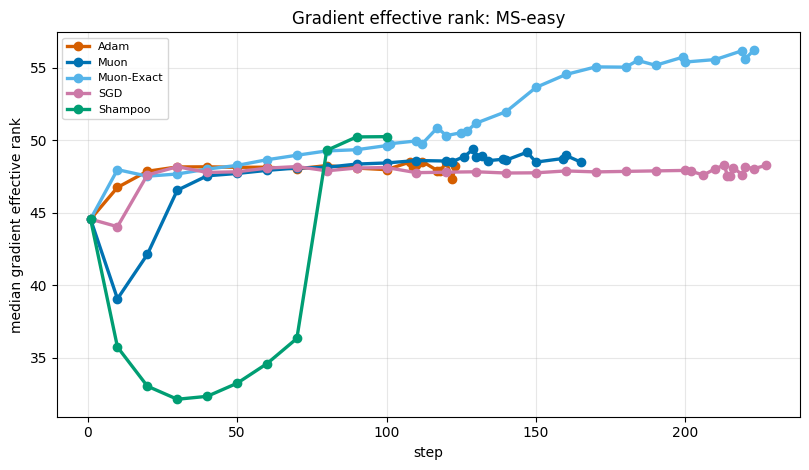

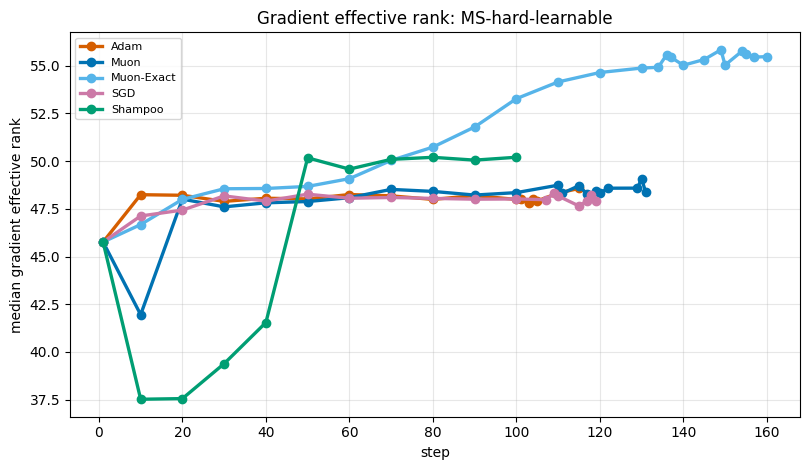

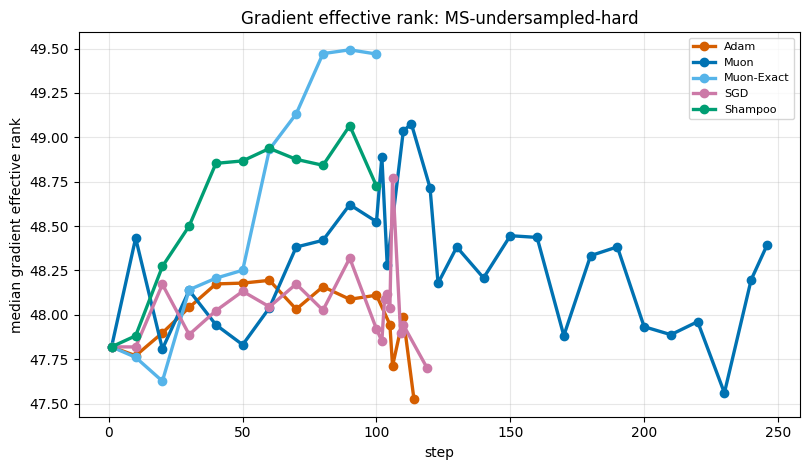

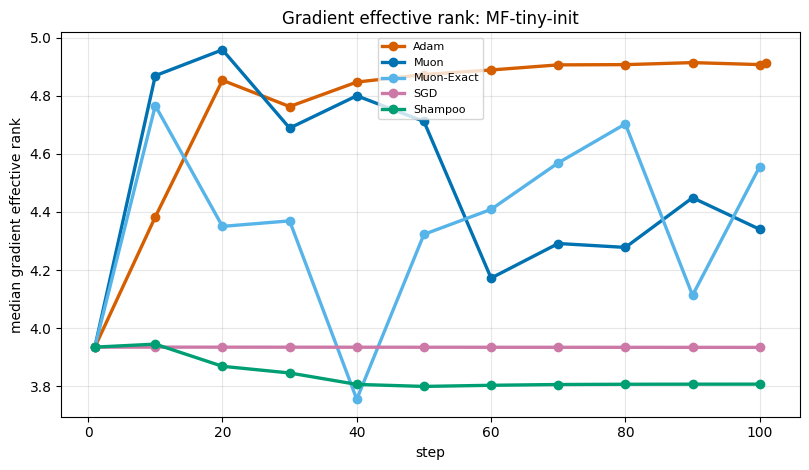

In [6]:
for setting in ["MS-easy", "MS-hard-learnable", "MS-undersampled-hard", "MF-tiny-init"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="grad_effective_rank",
        title=f"Gradient effective rank: {setting}",
        ylabel="median gradient effective rank",
    )
    show_figure(fig)


### Update Effective Rank

The Problem cell records optimizer updates $U_t$; this plot asks how spectrally complex those updates are after each method transforms the gradient.

This mirrors the gradient-rank plot but uses the actual optimizer update $U_t$. The horizontal axis is step, color is optimizer, and the vertical value is seed-median $r_{\mathrm{eff}}(U_t)$. Comparing this with gradient effective rank shows how much the optimizer changes the spectral geometry of the raw gradient before applying the step.

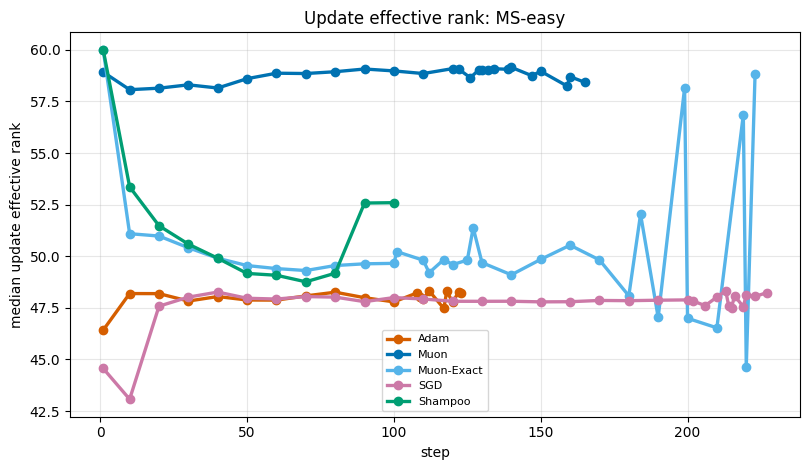

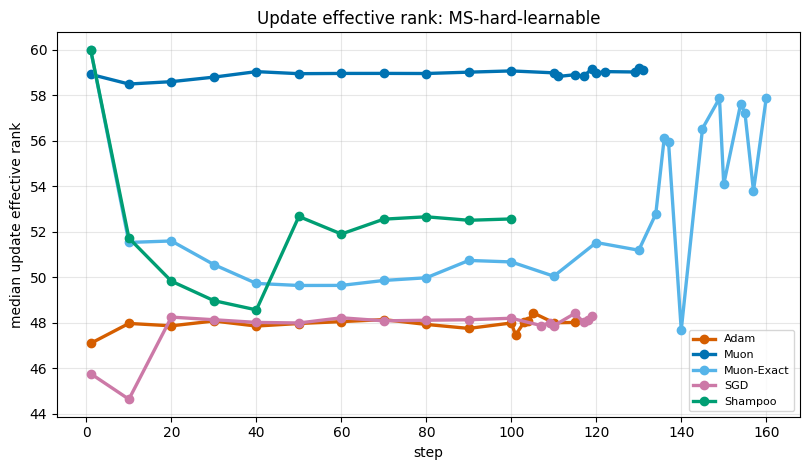

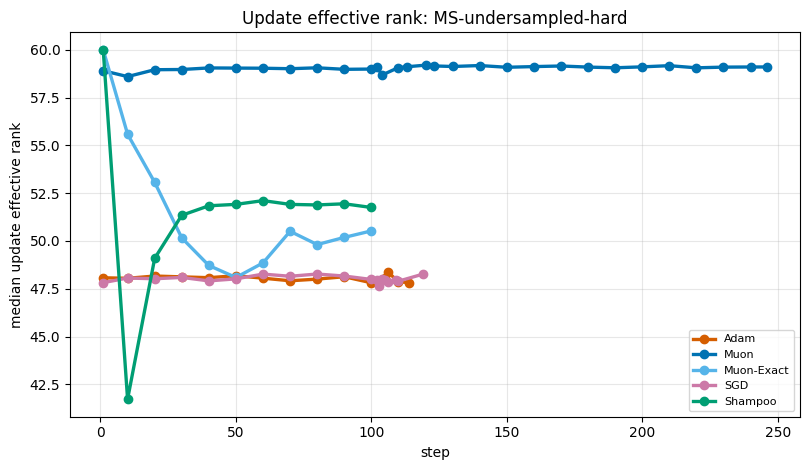

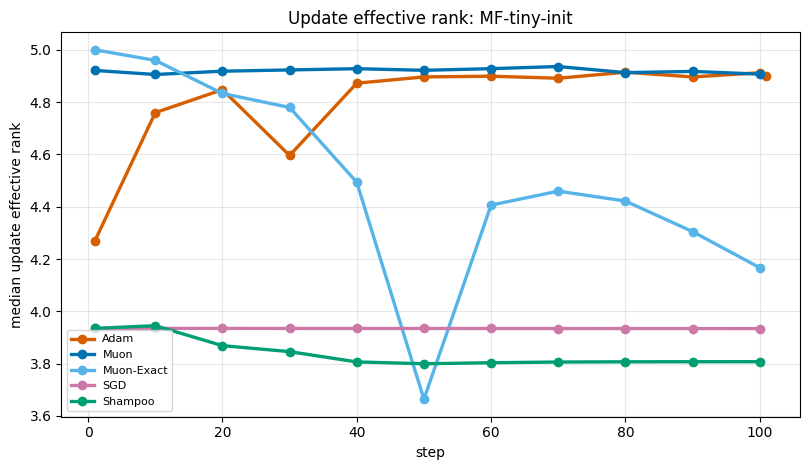

In [7]:
for setting in ["MS-easy", "MS-hard-learnable", "MS-undersampled-hard", "MF-tiny-init"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="update_effective_rank",
        title=f"Update effective rank: {setting}",
        ylabel="median update effective rank",
    )
    show_figure(fig)


### Gradient-Update Cosine

The Problem cell defines descent alignment $\cos_t$; this plot tracks that statistic over representative sensing and factorization settings.

Each figure fixes a representative setting. The horizontal axis is step $t$, color is optimizer, and the vertical value is the seed-median descent alignment $c_t=\langle -G_t,U_t\rangle/(\lVert G_t\rVert_F\lVert U_t\rVert_F)$. Values near $1$ point close to steepest descent, values near $0$ are nearly orthogonal, and negative values are locally ascent-like. The zero line is included so sign changes are easy to see.

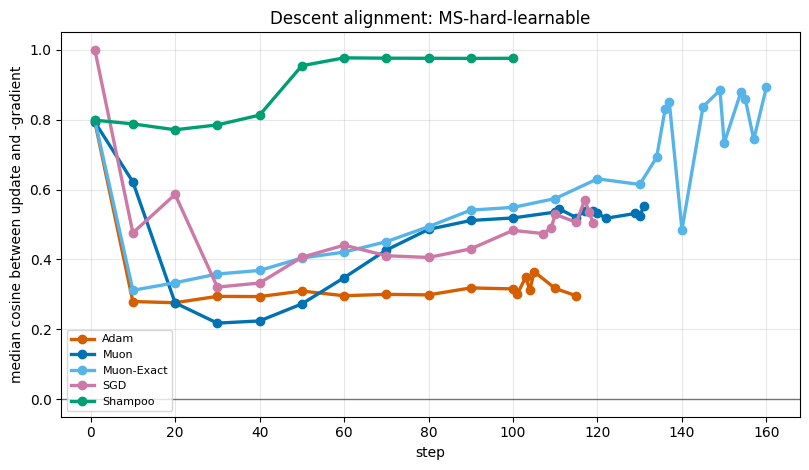

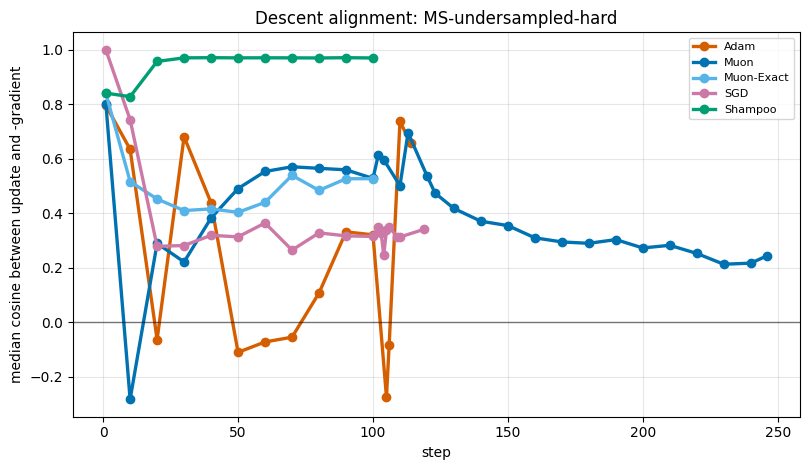

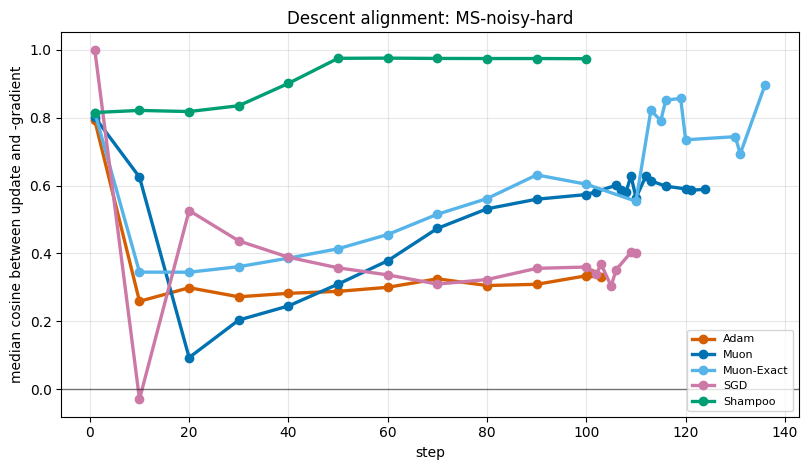

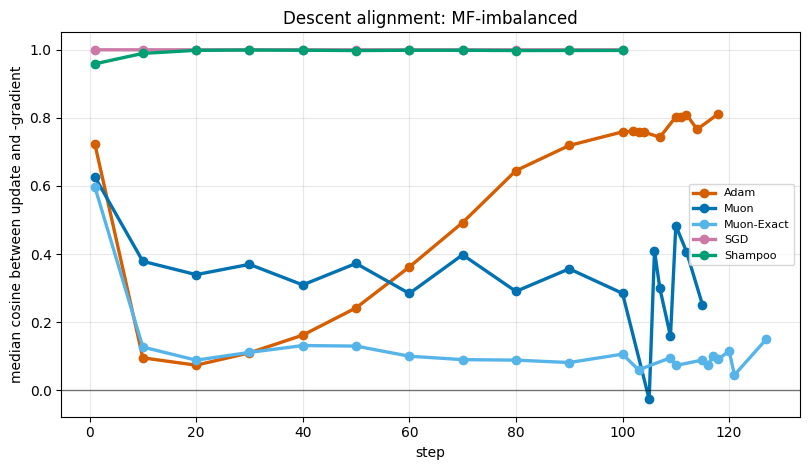

In [8]:
for setting in ["MS-hard-learnable", "MS-undersampled-hard", "MS-noisy-hard", "MF-imbalanced"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="grad_update_cosine",
        title=f"Descent alignment: {setting}",
        ylabel="median cosine between update and -gradient",
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.5)
    show_figure(fig)


### Relative Step Size

The Problem cell defines relative step size $\rho_t$; this plot shows that quantity in the factorized regimes where parameter scale is especially important.

These figures focus on Matrix Factorization settings. The horizontal axis is step $t$, color is optimizer, and the vertical value is the seed-median relative update magnitude $\lVert U_t\rVert_F/\lVert\theta_t\rVert_F$, where $\theta_t$ denotes the current factor parameters. The log vertical axis is intentional because overly large relative steps often explain instability from tiny or imbalanced initializations.

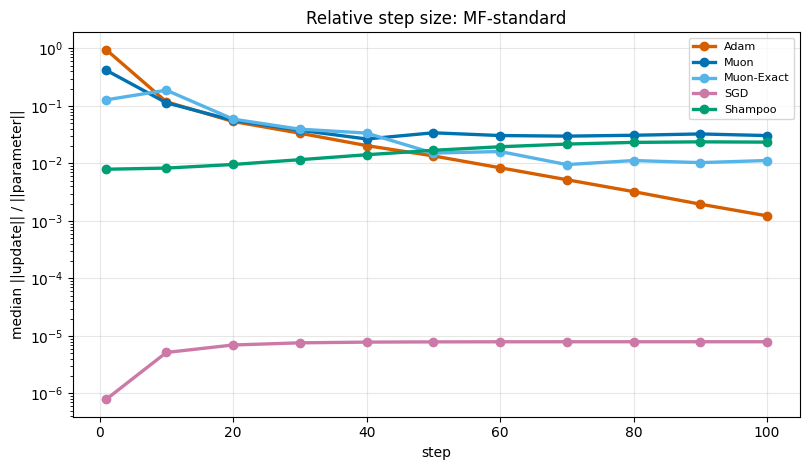

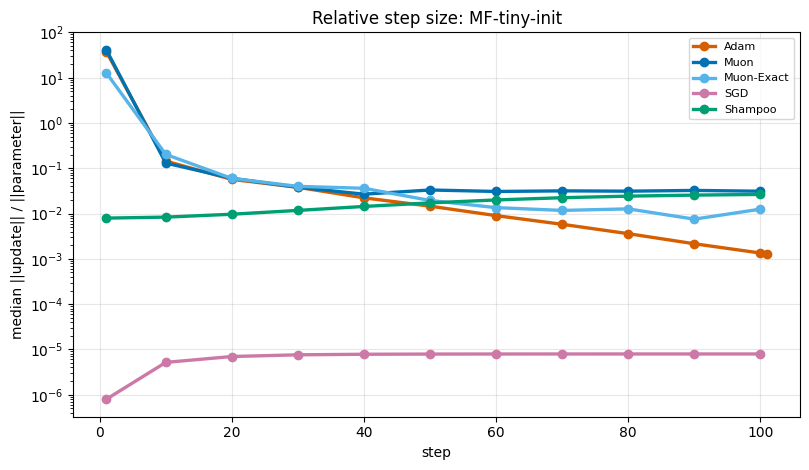

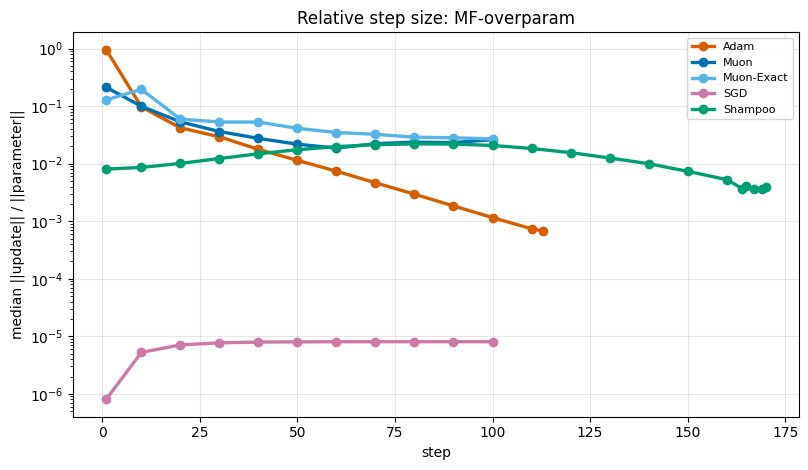

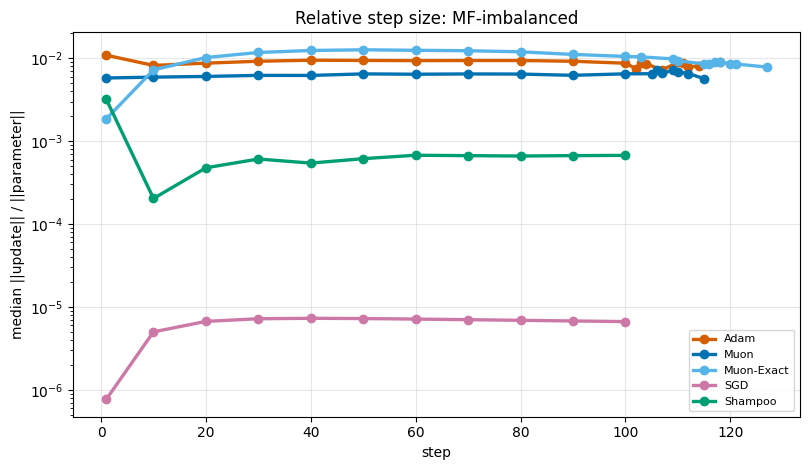

In [9]:
for setting in ["MF-standard", "MF-tiny-init", "MF-overparam", "MF-imbalanced"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="relative_step_size",
        title=f"Relative step size: {setting}",
        ylabel="median ||update|| / ||parameter||",
        log_y=True,
    )
    show_figure(fig)


### Singular-Value Recovery

The Problem cell also records represented matrices $\widehat X_t$; this plot checks whether their leading singular values approach those of $X^\star$.

Each figure fixes a representative setting and tracks spectral recovery over time. The horizontal axis is step $t$, color is optimizer, and the vertical value is seed-median top-$k$ singular-value error $\lVert \widehat s_{1:k,t}-s^\star_{1:k}\rVert_2/\lVert s^\star_{1:k}\rVert_2$ with $k=5$. This ignores singular-vector alignment and asks whether the optimizer recovers the target spectrum.

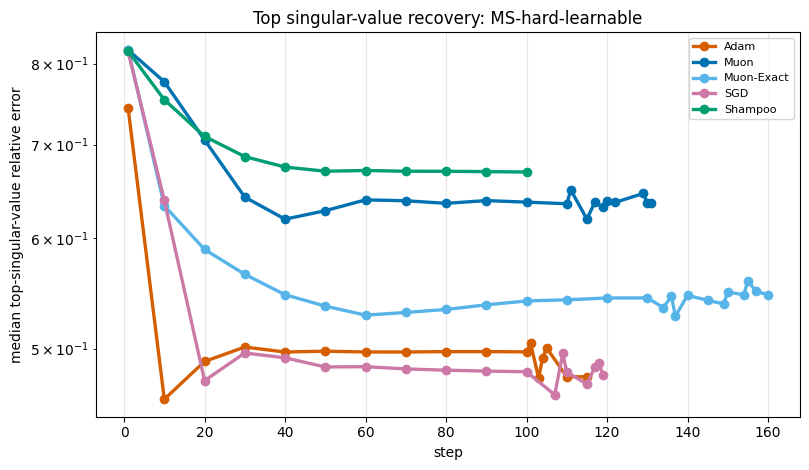

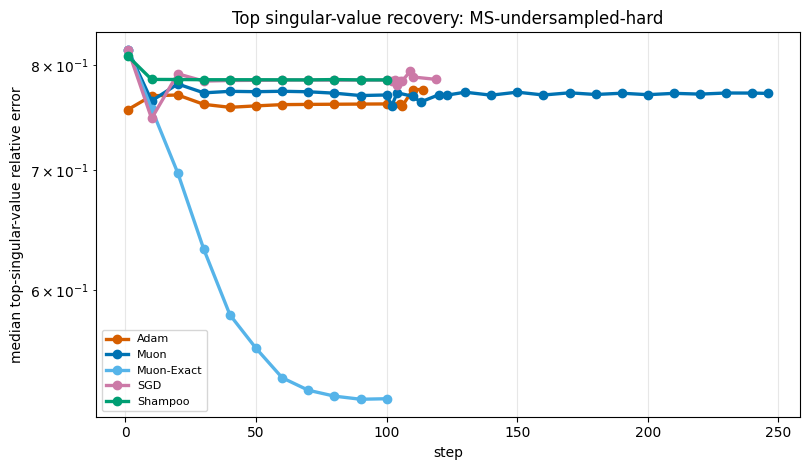

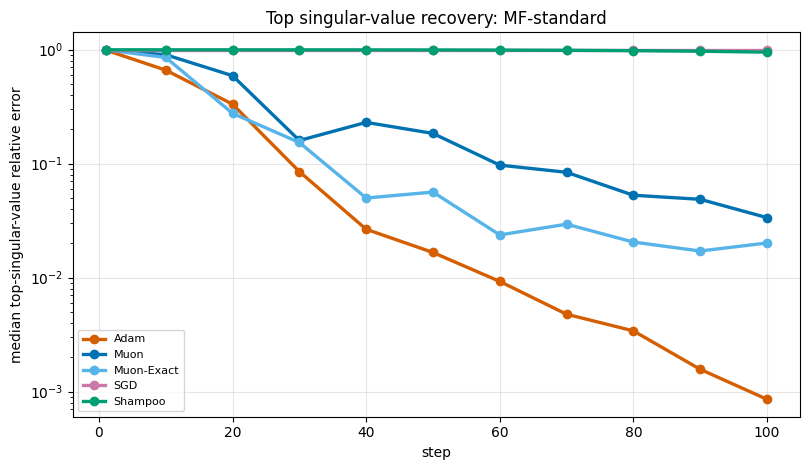

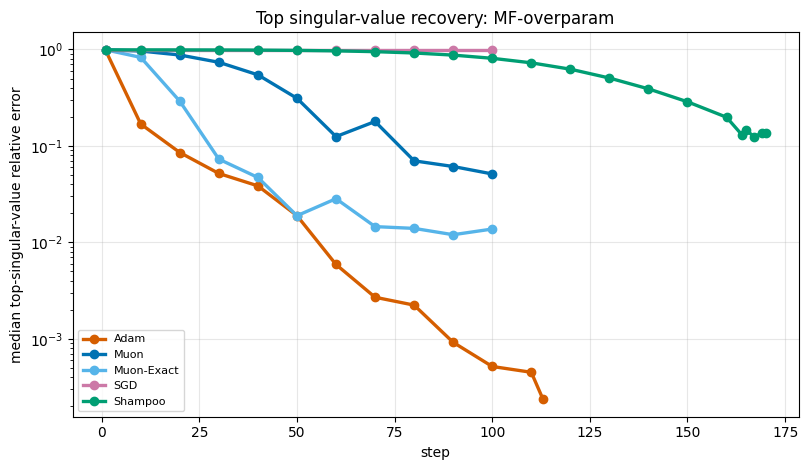

In [10]:
for setting in ["MS-hard-learnable", "MS-undersampled-hard", "MF-standard", "MF-overparam"]:
    fig, ax = plotting.plot_metric_lines(
        runs[runs["setting"] == setting],
        x="step",
        metric="top_sv_relative_error",
        title=f"Top singular-value recovery: {setting}",
        ylabel="median top-singular-value relative error",
        log_y=True,
    )
    show_figure(fig)


### Final Singular Values

This plot is the endpoint version of the Problem cell’s spectral recovery question, comparing the final recovered spectrum to the target spectrum.

Each generated figure fixes one setting and shows the final spectrum directly. The horizontal axis is singular-value index $1,\ldots,5$ and the vertical axis is singular value on a log scale. The black line is the target spectrum; colored lines are seed-median final recovered spectra for each optimizer. This is a direct check of which part of the spectrum each method over- or under-estimates.

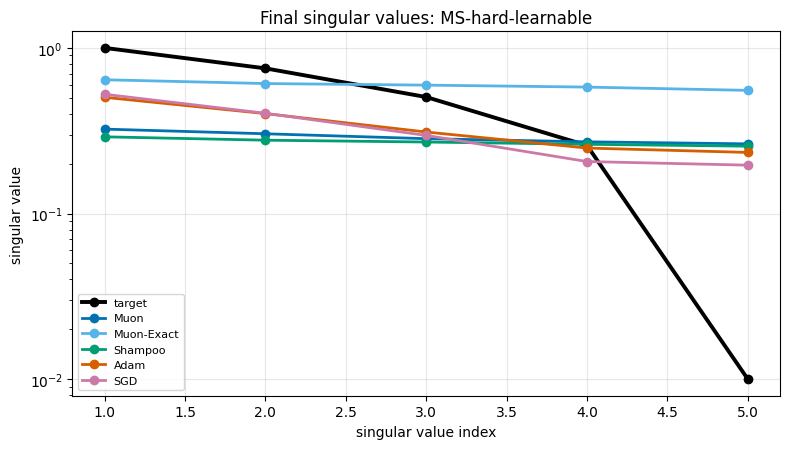

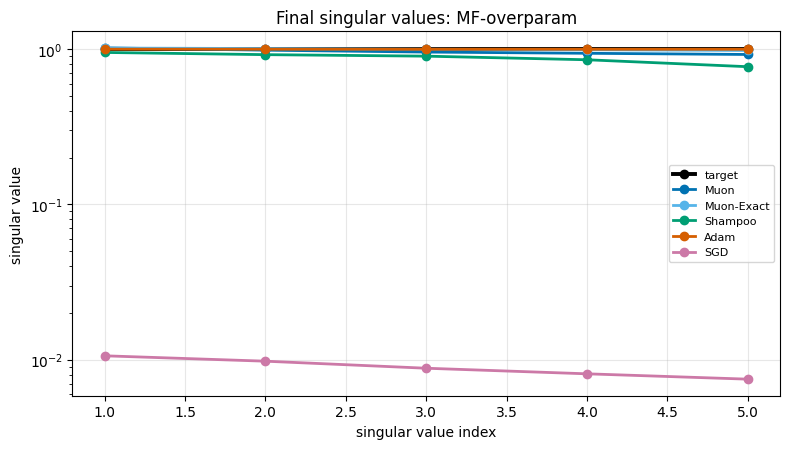

In [11]:
for setting in ["MS-hard-learnable", "MF-overparam"]:
    final_rows = runs[runs["setting"] == setting].sort_values("step").groupby(["algo", "seed"], as_index=False, observed=True).tail(1)
    median_sv = final_rows.groupby("algo", observed=True)[[f"solution_sv_{idx}" for idx in range(1, 6)]].median()
    target_sv = final_rows[[f"target_sv_{idx}" for idx in range(1, 6)]].iloc[0].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(8.0, 4.6))
    ax.plot(range(1, 6), target_sv, color="black", linewidth=2.8, marker="o", label="target")
    for algo in ALGOS:
        if algo in median_sv.index:
            ax.plot(range(1, 6), median_sv.loc[algo].to_numpy(dtype=float), color=plotting.algorithm_color(algo), linewidth=2.0, marker="o", label=algo)
    ax.set_title(f"Final singular values: {setting}")
    ax.set_xlabel("singular value index")
    ax.set_ylabel("singular value")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    show_figure(fig)


### Diagnostic Summary Table


In [12]:
diagnostic_table = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("relative_matrix_error", "median"),
    median_cosine=("grad_update_cosine", "median"),
    median_update_rank=("update_effective_rank", "median"),
    median_step_size=("relative_step_size", "median"),
    median_sv_error=("top_sv_relative_error", "median"),
    divergence_rate=("diverged", "mean"),
)
IPython.display.display(diagnostic_table)


,setting,algo,median_recovery,median_cosine,median_update_rank,median_step_size,median_sv_error,divergence_rate
0,MF-imbalanced,Adam,0.548110,0.768360,4.462920,0.008301,0.290191,0.0
1,MF-imbalanced,Muon,0.809838,0.284222,4.923040,0.006542,0.392588,0.0
2,MF-imbalanced,Muon-Exact,0.209117,0.089388,4.162454,0.008726,0.082978,0.0
3,MF-imbalanced,SGD,0.990674,0.999985,3.961236,0.000007,0.967938,0.0
4,MF-imbalanced,Shampoo,0.957988,0.998200,2.721513,0.000673,0.770622,0.0
5,MF-overparam,Adam,0.005096,0.298439,15.928560,0.001148,0.000513,0.0
6,MF-overparam,Muon,0.055276,0.215199,17.292247,0.026132,0.051174,0.0
7,MF-overparam,Muon-Exact,0.016001,0.211411,16.910471,0.026966,0.013731,0.0
8,MF-overparam,SGD,1.000142,1.000000,5.591341,0.000008,0.991070,0.0
9,MF-overparam,Shampoo,0.140867,1.000000,4.784469,0.003852,0.135949,0.0


### Reading The Result

A Muon win is more convincing if it coincides with lower recovery error, a distinctive update spectrum, and good singular-value recovery. If Muon loses when cosine alignment collapses or relative step size spikes, the failure is likely geometric rather than just a bad scalar learning rate.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Update geometry helps explain optimizer wins and failures. | The diagnostic table links recovery with gradient-update cosine, update rank, relative step size, and singular-value recovery. | Partial | The diagnostics are correlational; they do not prove that a spectral statistic causes the observed recovery. |
| Muon-family updates should look spectrally different from SGD/Adam/Shampoo. | Effective-rank, stable-rank, and top-singular-value panels compare gradients and updates by optimizer. | Yes | Distinct geometry is not automatically better geometry in every regime. |
